# RQ4 — Economic Meaningfulness of Final-Hour SPX Predictions

I test whether the out-of-fold RQ1-RQ3 predictions concentrate larger or more directionally predictable SPX moves into a smaller set of sessions.

**Research question:**  
*Can SPX price movements in the final hour be predicted with sufficient accuracy to be economically meaningful for trading applications?*

In this notebook, I bridge the statistical modelling in RQ1–RQ3 and the options-level trading backtest in RQ5.

I deliberately **do not calculate option P&L**. Instead it asks whether the out-of-fold predictions generated by the selected RQ1–RQ3 models identify sessions that are:

- more directionally predictable;
- associated with larger realised SPX moves;
- enriched for large-movement events;
- sufficiently selective to form plausible trade candidates.

The analysis uses **development-period outer-fold predictions only**. The post-17 July 2026 fresh holdout is not loaded or inspected here.

### Important interpretation rule

Some sections condition results on the **realised** final-hour move. Those analyses are diagnostic only because the realised move is not known at 15:00. They are used to understand whether forecasting quality changes when economically important movements occur; they are not executable trading rules.

Actual option premiums, strike selection, bid–ask spreads, slippage, commissions, Greeks, drawdown and strategy P&L are reserved for **RQ5**.

In [ ]:
# I resolve the repository root before running any project-relative paths.
from pathlib import Path
import os

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    # Path resolution still works before optional project dependencies are installed.
    def load_dotenv(*args, **kwargs):
        return False


def _find_project_root(start=None):
    location = Path(start or Path.cwd()).resolve()
    for candidate in (location, *location.parents):
        if (candidate / "config.yaml").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing config.yaml.")


PROJECT_ROOT = _find_project_root()
# The original notebooks were written from the repository root. Keeping that
# working directory preserves every existing data, output and model path.
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / "main.env")
print(f"Project root: {PROJECT_ROOT}")


## 1. Imports, project paths and analysis configuration

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

ECONOMIC_THRESHOLDS_BPS = [0, 10, 15, 20, 25, 30, 40, 50]
PREDICTED_MAGNITUDE_THRESHOLDS_BPS = [10, 15, 20, 25, 30, 40]
SELECTIVE_COVERAGES = [1.00, 0.50, 0.30, 0.20, 0.10]

# Pre-specified from the earlier robustness result.
PRIMARY_RQ1_COVERAGE = 0.30

# Fixed reference for compact combined-rule tables; the full threshold grid
# is still reported separately.
PRIMARY_PREDICTED_MAGNITUDE_BPS = 20

MIN_REGIME_SESSIONS = 10

# Moving-block bootstrap settings.
N_BOOTSTRAPS = 2_000
BOOTSTRAP_BLOCK_LENGTH = 5
CONFIDENCE_LEVEL = 0.95

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "market.duckdb").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DERIVED_ROOT = PROJECT_ROOT / "data" / "derived"

TUNING_ROOT = PROJECT_ROOT / "outputs" / "hyperparameter_tuning"
TUNING_TABLE_ROOT = TUNING_ROOT / "tables"

RQ4_ROOT = PROJECT_ROOT / "outputs" / "rq4_economic_meaningfulness"
RQ4_TABLE_ROOT = RQ4_ROOT / "tables"
RQ4_FIGURE_ROOT = RQ4_ROOT / "figures"

RQ4_ROOT.mkdir(parents=True, exist_ok=True)
RQ4_TABLE_ROOT.mkdir(parents=True, exist_ok=True)
RQ4_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

OOF_PATH = TUNING_TABLE_ROOT / "selected_winner_outer_fold_predictions.csv"
WINNERS_PATH = TUNING_TABLE_ROOT / "nested_tuned_winners.csv"

STRICT_PATH = DERIVED_ROOT / "daily_underlying_model_dataset_strict_split.parquet"
RELAXED_PATH = DERIVED_ROOT / "daily_underlying_model_dataset_relaxed_split.parquet"

required_paths = [OOF_PATH, WINNERS_PATH, STRICT_PATH, RELAXED_PATH]
missing_paths = [str(path) for path in required_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Required inputs are missing. Run the extended robustness notebook first "
        "and ensure the strict/relaxed datasets exist.\nMissing:\n- "
        + "\n- ".join(missing_paths)
    )

print("Project root:", PROJECT_ROOT)
print("RQ4 output root:", RQ4_ROOT)
print("Outer-fold predictions:", OOF_PATH)
print("Fresh holdout status: NOT LOADED")

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
RQ4 output root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness
Outer-fold predictions: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\selected_winner_outer_fold_predictions.csv
Fresh holdout status: NOT LOADED


## 2. Load outer-fold predictions and source market data

In [2]:
def load_source_variant(path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(path).copy()
    frame["session_date"] = pd.to_datetime(frame["session_date"])
    frame = frame.sort_values("session_date").reset_index(drop=True)

    required = {
        "session_date",
        "final_hour_return",
        "spx_at_1500",
        "target_up",
        "ret_last_60m",
        "vix_level_1500",
        "realized_vol_60m",
        "ret_open_to_1500",
    }

    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(
            f"{path.name} is missing required columns: {sorted(missing)}"
        )

    frame["actual_abs_move_bps"] = frame["final_hour_return"].abs() * 10_000
    frame["actual_signed_move_bps"] = frame["final_hour_return"] * 10_000

    # Converts the simple return to an approximate SPX index-point move.
    frame["actual_move_points"] = (
        frame["final_hour_return"].abs() * frame["spx_at_1500"]
    )

    return frame


strict_data = load_source_variant(STRICT_PATH)
relaxed_data = load_source_variant(RELAXED_PATH)

datasets = {
    "Strict": strict_data,
    "Relaxed": relaxed_data,
}

oof = pd.read_csv(OOF_PATH)
oof["session_date"] = pd.to_datetime(oof["session_date"])

winners = pd.read_csv(WINNERS_PATH)

expected_rqs = {
    "RQ1 Direction",
    "RQ2 Magnitude",
    "RQ3 Large Movement",
}
missing_rqs = expected_rqs.difference(set(oof["research_question"].unique()))
if missing_rqs:
    raise ValueError(
        f"Outer-fold prediction file is missing: {sorted(missing_rqs)}"
    )

display(winners)
print("OOF rows:", len(oof))
print("OOF date range:", oof["session_date"].min(), "to", oof["session_date"].max())
print("Rows by RQ:")
display(oof.groupby("research_question").size().rename("rows").to_frame())

,research_question,dataset_variant,feature_set,model,primary_metric,outer_score,outer_standard_deviation
0,RQ1 Direction,Relaxed,Full,Histogram Gradient Boosting,Balanced accuracy,0.543904,0.070448
1,RQ2 Magnitude,Relaxed,Reduced,RBF SVR,MAE in basis points,13.967479,5.406184
2,RQ3 Large Movement,Strict,Full,RBF SVC,Average precision,0.501411,0.189125


OOF rows: 882
OOF date range: 2024-12-16 00:00:00 to 2026-03-20 00:00:00
Rows by RQ:


,rows
research_question,
RQ1 Direction,303
RQ2 Magnitude,303
RQ3 Large Movement,276


## 3. Build RQ-specific economic prediction frames

In [3]:
def selected_variant_for_rq(research_question: str) -> str:
    row = winners[
        winners["research_question"].eq(research_question)
    ]
    if len(row) != 1:
        raise ValueError(
            f"Expected one winner row for {research_question}, found {len(row)}."
        )
    return str(row.iloc[0]["dataset_variant"])


def build_rq_frame(research_question: str) -> pd.DataFrame:
    predictions = (
        oof[oof["research_question"].eq(research_question)]
        .copy()
        .sort_values("session_date")
        .reset_index(drop=True)
    )

    variant = selected_variant_for_rq(research_question)
    source = datasets[variant].copy()

    source_columns = [
        "session_date",
        "final_hour_return",
        "actual_abs_move_bps",
        "actual_signed_move_bps",
        "actual_move_points",
        "spx_at_1500",
        "target_up",
        "ret_last_60m",
        "vix_level_1500",
        "realized_vol_60m",
        "ret_open_to_1500",
    ]

    merged = predictions.merge(
        source[source_columns],
        on="session_date",
        how="left",
        validate="one_to_one",
    )

    if merged["final_hour_return"].isna().any():
        missing_dates = merged.loc[
            merged["final_hour_return"].isna(), "session_date"
        ].dt.strftime("%Y-%m-%d").tolist()
        raise ValueError(
            f"{research_question}: source rows missing for {missing_dates[:10]}"
        )

    merged["selected_dataset_variant"] = variant
    return merged


rq1 = build_rq_frame("RQ1 Direction")
rq2 = build_rq_frame("RQ2 Magnitude")
rq3 = build_rq_frame("RQ3 Large Movement")

# Reconstruct the strongest simple comparator from the robustness run.
rq1["mean_reversion_60m_prediction"] = (
    rq1["ret_last_60m"] < 0
).astype(int)

rq1["rq1_correct"] = (
    rq1["prediction"].astype(int) == rq1["y_true"].astype(int)
)

rq1["mean_reversion_correct"] = (
    rq1["mean_reversion_60m_prediction"].astype(int)
    == rq1["y_true"].astype(int)
)

# Positive = RQ1 direction aligned with the realised SPX move.
# This is NOT option P&L.
rq1["directional_capture_bps"] = np.where(
    rq1["prediction"].astype(int).eq(1),
    rq1["actual_signed_move_bps"],
    -rq1["actual_signed_move_bps"],
)

print("RQ1 selected variant:", selected_variant_for_rq("RQ1 Direction"))
print("RQ2 selected variant:", selected_variant_for_rq("RQ2 Magnitude"))
print("RQ3 selected variant:", selected_variant_for_rq("RQ3 Large Movement"))

display(
    pd.DataFrame(
        {
            "RQ": ["RQ1", "RQ2", "RQ3"],
            "sessions": [len(rq1), len(rq2), len(rq3)],
            "first_date": [
                rq1["session_date"].min(),
                rq2["session_date"].min(),
                rq3["session_date"].min(),
            ],
            "last_date": [
                rq1["session_date"].max(),
                rq2["session_date"].max(),
                rq3["session_date"].max(),
            ],
        }
    )
)

RQ1 selected variant: Relaxed
RQ2 selected variant: Relaxed
RQ3 selected variant: Strict


,RQ,sessions,first_date,last_date
0,RQ1,303,2024-12-16,2026-03-20
1,RQ2,303,2024-12-16,2026-03-20
2,RQ3,276,2024-12-17,2026-03-20


## 4. Metric helpers

Balanced accuracy is reported only when both outcome classes are present in the evaluated subset. This avoids giving a misleading directional score to tiny threshold or regime subsets containing only one class.

In [4]:
# I use this cell for metric helpers.
def safe_balanced_accuracy(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(balanced_accuracy_score(y_true, y_pred))


def safe_mcc(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(np.unique(y_true)) < 2 or len(np.unique(y_pred)) < 2:
        return np.nan
    return float(matthews_corrcoef(y_true, y_pred))


def direction_metrics(frame: pd.DataFrame, prediction_col: str) -> dict:
    if frame.empty:
        return {
            "balanced_accuracy": np.nan,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "mcc": np.nan,
        }

    y_true = frame["y_true"].astype(int)
    y_pred = frame[prediction_col].astype(int)

    return {
        "balanced_accuracy": safe_balanced_accuracy(y_true, y_pred),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": safe_mcc(y_true, y_pred),
    }


def economic_summary(frame: pd.DataFrame) -> dict:
    if frame.empty:
        return {
            "sessions": 0,
            "mean_abs_move_bps": np.nan,
            "median_abs_move_bps": np.nan,
            "mean_move_points": np.nan,
            "median_move_points": np.nan,
            "rate_ge_20bps": np.nan,
            "rate_ge_30bps": np.nan,
            "rate_ge_40bps": np.nan,
        }

    return {
        "sessions": int(len(frame)),
        "mean_abs_move_bps": float(frame["actual_abs_move_bps"].mean()),
        "median_abs_move_bps": float(frame["actual_abs_move_bps"].median()),
        "mean_move_points": float(frame["actual_move_points"].mean()),
        "median_move_points": float(frame["actual_move_points"].median()),
        "rate_ge_20bps": float((frame["actual_abs_move_bps"] >= 20).mean()),
        "rate_ge_30bps": float((frame["actual_abs_move_bps"] >= 30).mean()),
        "rate_ge_40bps": float((frame["actual_abs_move_bps"] >= 40).mean()),
    }


def save_table(frame: pd.DataFrame, filename: str) -> Path:
    path = RQ4_TABLE_ROOT / filename
    frame.to_csv(path, index=False)
    print("Saved:", path)
    return path


def save_figure(fig, filename: str) -> Path:
    path = RQ4_FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    print("Saved:", path)
    return path

## 5. Analysis A — Directional usefulness conditional on realised movement size

This is an **ex-post diagnostic**, not a tradable filter. A trader at 15:00 does not know whether the subsequent move will exceed 20, 30 or 40 basis points.

The purpose is to test whether directional forecasting becomes more or less reliable specifically on sessions that ultimately produce economically larger moves. The selected RQ1 model is compared with the 60-minute mean-reversion rule on the **same observations**.

,minimum_realised_move_bps,sessions,up_share,model_balanced_accuracy,mean_reversion_balanced_accuracy,model_minus_benchmark_ba,model_accuracy,mean_reversion_accuracy,mean_abs_move_bps,median_abs_move_bps,mean_move_points
0,0,303,0.455446,0.531884,0.566930,-0.035046,0.537954,0.570957,21.719373,14.199470,13.324620
1,10,196,0.489796,0.493333,0.565833,-0.072500,0.494898,0.566327,30.928103,22.326749,18.930612
2,15,143,0.489510,0.473973,0.601370,-0.127397,0.475524,0.601399,37.799242,28.554871,22.982517
3,20,113,0.477876,0.430163,0.593691,-0.163528,0.433628,0.592920,43.294704,35.320536,26.143540
4,25,87,0.436782,0.468582,0.617615,-0.149033,0.471264,0.609195,49.592152,40.448154,29.822184
5,30,69,0.405797,0.506098,0.601916,-0.095819,0.507246,0.594203,55.381815,42.846187,33.184638
6,40,44,0.454545,0.475000,0.570833,-0.095833,0.477273,0.568182,66.958336,55.776890,39.853636
7,50,24,0.458333,0.489510,0.671329,-0.181818,0.500000,0.666667,86.791863,70.151551,50.639167


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_direction_conditional_on_realised_move.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\figures\rq4_direction_by_realised_move_threshold.png


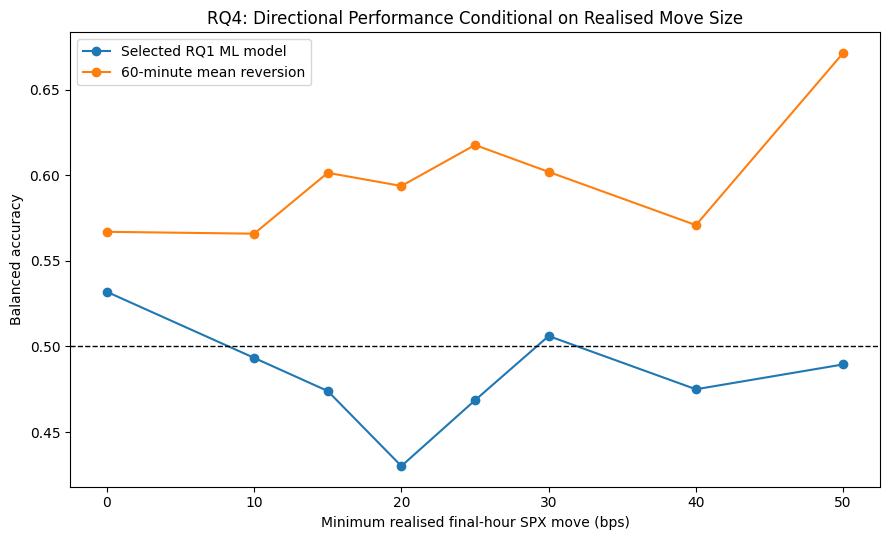

In [5]:
# I use this cell for analysis a - directional usefulness conditional on realised movement size.
conditional_rows = []

for threshold_bps in ECONOMIC_THRESHOLDS_BPS:
    subset = rq1[
        rq1["actual_abs_move_bps"] >= threshold_bps
    ].copy()

    model_metrics = direction_metrics(subset, "prediction")
    benchmark_metrics = direction_metrics(
        subset,
        "mean_reversion_60m_prediction",
    )

    conditional_rows.append(
        {
            "minimum_realised_move_bps": threshold_bps,
            "sessions": len(subset),
            "up_share": (
                float(subset["y_true"].mean())
                if len(subset)
                else np.nan
            ),
            "model_balanced_accuracy": model_metrics["balanced_accuracy"],
            "mean_reversion_balanced_accuracy": (
                benchmark_metrics["balanced_accuracy"]
            ),
            "model_minus_benchmark_ba": (
                model_metrics["balanced_accuracy"]
                - benchmark_metrics["balanced_accuracy"]
                if np.isfinite(model_metrics["balanced_accuracy"])
                and np.isfinite(benchmark_metrics["balanced_accuracy"])
                else np.nan
            ),
            "model_accuracy": model_metrics["accuracy"],
            "mean_reversion_accuracy": benchmark_metrics["accuracy"],
            "mean_abs_move_bps": (
                subset["actual_abs_move_bps"].mean()
                if len(subset)
                else np.nan
            ),
            "median_abs_move_bps": (
                subset["actual_abs_move_bps"].median()
                if len(subset)
                else np.nan
            ),
            "mean_move_points": (
                subset["actual_move_points"].mean()
                if len(subset)
                else np.nan
            ),
        }
    )

conditional_direction = pd.DataFrame(conditional_rows)
display(conditional_direction)
save_table(
    conditional_direction,
    "rq4_direction_conditional_on_realised_move.csv",
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(
    conditional_direction["minimum_realised_move_bps"],
    conditional_direction["model_balanced_accuracy"],
    marker="o",
    label="Selected RQ1 ML model",
)
ax.plot(
    conditional_direction["minimum_realised_move_bps"],
    conditional_direction["mean_reversion_balanced_accuracy"],
    marker="o",
    label="60-minute mean reversion",
)
ax.axhline(0.50, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Minimum realised final-hour SPX move (bps)")
ax.set_ylabel("Balanced accuracy")
ax.set_title("RQ4: Directional Performance Conditional on Realised Move Size")
ax.legend()
save_figure(fig, "rq4_direction_by_realised_move_threshold.png")
plt.show()

## 6. Analysis B — RQ1 confidence versus economic movement

,requested_coverage,realised_coverage,sessions,mean_abs_move_bps,median_abs_move_bps,mean_move_points,median_move_points,rate_ge_20bps,rate_ge_30bps,rate_ge_40bps,model_balanced_accuracy,mean_reversion_balanced_accuracy,model_minus_benchmark_ba,model_accuracy,model_mcc,mean_directional_capture_bps,median_directional_capture_bps,mean_abs_move_when_correct_bps,mean_abs_move_when_wrong_bps
0,1.000000,1.000000,303,21.719373,14.199470,13.324620,8.950000,0.372937,0.227723,0.145215,0.531884,0.566930,-0.035046,0.537954,0.064164,-0.608593,0.806656,19.621369,24.162049
1,0.500000,0.504950,153,20.867816,14.184541,12.937451,9.310000,0.398693,0.209150,0.130719,0.560664,0.580070,-0.019406,0.568627,0.120886,1.642828,3.010396,19.793842,22.283509
2,0.300000,0.306931,93,19.521659,12.928759,12.243226,8.410000,0.365591,0.204301,0.107527,0.591699,0.582770,0.008929,0.602151,0.181310,1.157796,3.118585,17.171334,23.078909
3,0.200000,0.207921,63,19.922244,14.122514,12.581746,9.000000,0.396825,0.206349,0.095238,0.560811,0.580042,-0.019231,0.571429,0.120994,-2.542926,1.279275,15.206903,26.209365
4,0.100000,0.108911,33,21.252577,15.149976,13.399091,9.610000,0.454545,0.242424,0.151515,0.503759,0.520677,-0.016917,0.515152,0.007519,-2.103095,2.320963,18.586262,24.085536


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_rq1_confidence_economic_analysis.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\figures\rq4_confidence_vs_accuracy_and_move_size.png


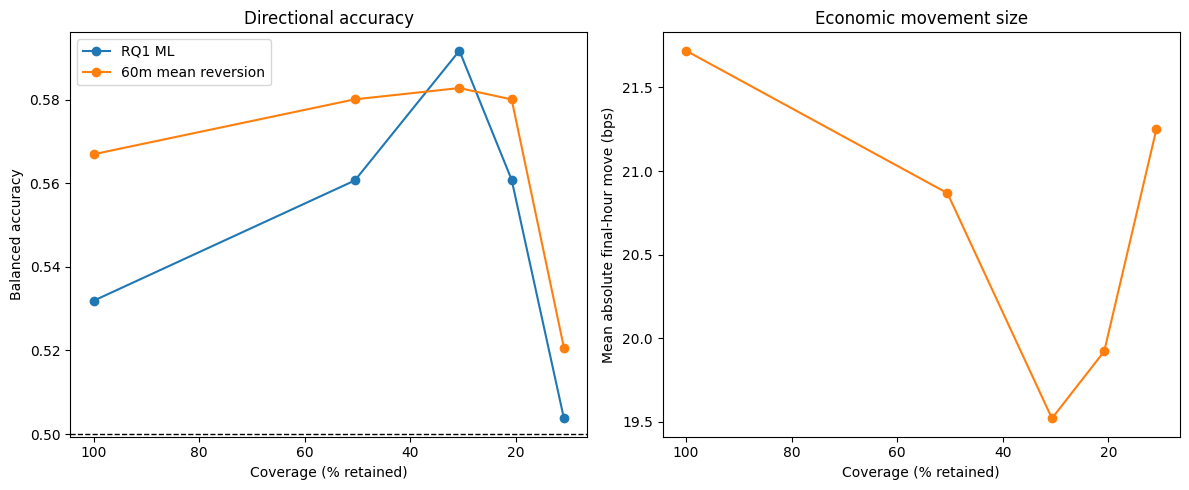

In [6]:
# I use this cell for analysis b - rq1 confidence versus economic movement.
selective_rows = []

for coverage in SELECTIVE_COVERAGES:
    minimum_percentile = 1.0 - coverage

    selected = rq1[
        rq1["confidence_percentile"] > minimum_percentile
    ].copy()

    model_metrics = direction_metrics(selected, "prediction")
    benchmark_metrics = direction_metrics(
        selected,
        "mean_reversion_60m_prediction",
    )
    econ = economic_summary(selected)

    correct = selected[selected["rq1_correct"]]
    wrong = selected[~selected["rq1_correct"]]

    selective_rows.append(
        {
            "requested_coverage": coverage,
            "realised_coverage": len(selected) / len(rq1),
            **econ,
            "model_balanced_accuracy": model_metrics["balanced_accuracy"],
            "mean_reversion_balanced_accuracy": (
                benchmark_metrics["balanced_accuracy"]
            ),
            "model_minus_benchmark_ba": (
                model_metrics["balanced_accuracy"]
                - benchmark_metrics["balanced_accuracy"]
                if np.isfinite(model_metrics["balanced_accuracy"])
                and np.isfinite(benchmark_metrics["balanced_accuracy"])
                else np.nan
            ),
            "model_accuracy": model_metrics["accuracy"],
            "model_mcc": model_metrics["mcc"],
            "mean_directional_capture_bps": (
                selected["directional_capture_bps"].mean()
            ),
            "median_directional_capture_bps": (
                selected["directional_capture_bps"].median()
            ),
            "mean_abs_move_when_correct_bps": (
                correct["actual_abs_move_bps"].mean()
                if len(correct)
                else np.nan
            ),
            "mean_abs_move_when_wrong_bps": (
                wrong["actual_abs_move_bps"].mean()
                if len(wrong)
                else np.nan
            ),
        }
    )

selective_economic = pd.DataFrame(selective_rows)
display(selective_economic)
save_table(
    selective_economic,
    "rq4_rq1_confidence_economic_analysis.csv",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    selective_economic["realised_coverage"] * 100,
    selective_economic["model_balanced_accuracy"],
    marker="o",
    label="RQ1 ML",
)
axes[0].plot(
    selective_economic["realised_coverage"] * 100,
    selective_economic["mean_reversion_balanced_accuracy"],
    marker="o",
    label="60m mean reversion",
)
axes[0].axhline(0.50, color="black", linestyle="--", linewidth=1)
axes[0].invert_xaxis()
axes[0].set_xlabel("Coverage (% retained)")
axes[0].set_ylabel("Balanced accuracy")
axes[0].set_title("Directional accuracy")
axes[0].legend()

axes[1].plot(
    selective_economic["realised_coverage"] * 100,
    selective_economic["mean_abs_move_bps"],
    marker="o",
    color="tab:orange",
)
axes[1].invert_xaxis()
axes[1].set_xlabel("Coverage (% retained)")
axes[1].set_ylabel("Mean absolute final-hour move (bps)")
axes[1].set_title("Economic movement size")

save_figure(fig, "rq4_confidence_vs_accuracy_and_move_size.png")
plt.show()

## 7. Join RQ1, RQ2 and RQ3 out-of-fold predictions

The selected RQ1 and RQ2 configurations may use a different data-eligibility variant from RQ3. Their expanding-window test blocks therefore do not necessarily start and end on identical dates.

For the combined opportunity analysis, I use the **intersection of session dates for which all three selected models produced genuine outer-fold predictions**. No missing model output is filled or extrapolated.

In [7]:
# I use this cell for join rq1, rq2 and rq3 out-of-fold predictions.
rq1_join = rq1[
    [
        "session_date",
        "prediction",
        "score",
        "threshold",
        "confidence_percentile",
        "outer_fold",
        "vix_regime",
        "realized_vol_regime",
        "intraday_trend_regime",
        "final_hour_return",
        "actual_abs_move_bps",
        "actual_signed_move_bps",
        "actual_move_points",
        "spx_at_1500",
        "ret_last_60m",
        "y_true",
        "directional_capture_bps",
    ]
].rename(
    columns={
        "prediction": "rq1_prediction",
        "score": "rq1_score",
        "threshold": "rq1_threshold",
        "confidence_percentile": "rq1_confidence_percentile",
        "outer_fold": "rq1_outer_fold",
        "y_true": "actual_up",
    }
)

rq2_join = rq2[
    [
        "session_date",
        "prediction",
        "score",
        "outer_fold",
    ]
].rename(
    columns={
        "prediction": "rq2_predicted_move_bps",
        "score": "rq2_score",
        "outer_fold": "rq2_outer_fold",
    }
)

rq3_join = rq3[
    [
        "session_date",
        "prediction",
        "score",
        "threshold",
        "score_percentile",
        "outer_fold",
        "y_true",
    ]
].rename(
    columns={
        "prediction": "rq3_large_move_prediction",
        "score": "rq3_score",
        "threshold": "rq3_threshold",
        "score_percentile": "rq3_score_percentile",
        "outer_fold": "rq3_outer_fold",
        "y_true": "actual_large_move",
    }
)

combined = (
    rq1_join
    .merge(rq2_join, on="session_date", how="inner", validate="one_to_one")
    .merge(rq3_join, on="session_date", how="inner", validate="one_to_one")
    .sort_values("session_date")
    .reset_index(drop=True)
)

combined["rq1_high_confidence"] = (
    combined["rq1_confidence_percentile"]
    > (1.0 - PRIMARY_RQ1_COVERAGE)
)

combined["rq3_positive"] = (
    combined["rq3_large_move_prediction"].astype(int).eq(1)
)

print("RQ1 OOF sessions:", len(rq1))
print("RQ2 OOF sessions:", len(rq2))
print("RQ3 OOF sessions:", len(rq3))
print("Three-model intersection:", len(combined))
print(
    "Intersection date range:",
    combined["session_date"].min(),
    "to",
    combined["session_date"].max(),
)

save_table(
    combined,
    "rq4_combined_outer_fold_predictions.csv",
)

RQ1 OOF sessions: 303
RQ2 OOF sessions: 303
RQ3 OOF sessions: 276
Three-model intersection: 276
Intersection date range: 2024-12-17 00:00:00 to 2026-03-20 00:00:00
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_combined_outer_fold_predictions.csv


WindowsPath('C:/Users/hkhat/OneDrive/Desktop/Project/Dissertation/outputs/rq4_economic_meaningfulness/tables/rq4_combined_outer_fold_predictions.csv')

## 8. Analysis C — Combined RQ1 + RQ2 + RQ3 opportunity filters

The combined rules are **development-period opportunity diagnostics**, not options strategies.

- RQ1 supplies direction.
- RQ2 supplies predicted absolute movement magnitude.
- RQ3 supplies a fold-specific large-movement flag.
- RQ1 confidence is restricted using the previously analysed 30% coverage operating point.

The RQ2 threshold is deliberately shown across a grid rather than selecting whichever threshold looks best.

In [8]:
# I use this cell for analysis c - combined rq1 + rq2 + rq3 opportunity filters.
def signal_summary(
    frame: pd.DataFrame,
    mask: pd.Series,
    rule_name: str,
    predicted_threshold=np.nan,
) -> dict:
    selected = frame[mask].copy()

    if selected.empty:
        return {
            "rule": rule_name,
            "predicted_magnitude_threshold_bps": predicted_threshold,
            "sessions": 0,
            "coverage": 0.0,
            "direction_balanced_accuracy": np.nan,
            "direction_accuracy": np.nan,
            "mean_abs_move_bps": np.nan,
            "median_abs_move_bps": np.nan,
            "mean_move_points": np.nan,
            "mean_directional_capture_bps": np.nan,
            "rate_ge_20bps": np.nan,
            "rate_ge_30bps": np.nan,
            "rate_ge_40bps": np.nan,
        }

    direction_ba = safe_balanced_accuracy(
        selected["actual_up"].astype(int),
        selected["rq1_prediction"].astype(int),
    )

    return {
        "rule": rule_name,
        "predicted_magnitude_threshold_bps": predicted_threshold,
        "sessions": len(selected),
        "coverage": len(selected) / len(frame),
        "direction_balanced_accuracy": direction_ba,
        "direction_accuracy": accuracy_score(
            selected["actual_up"].astype(int),
            selected["rq1_prediction"].astype(int),
        ),
        "mean_abs_move_bps": selected["actual_abs_move_bps"].mean(),
        "median_abs_move_bps": selected["actual_abs_move_bps"].median(),
        "mean_move_points": selected["actual_move_points"].mean(),
        "mean_directional_capture_bps": selected["directional_capture_bps"].mean(),
        "rate_ge_20bps": (selected["actual_abs_move_bps"] >= 20).mean(),
        "rate_ge_30bps": (selected["actual_abs_move_bps"] >= 30).mean(),
        "rate_ge_40bps": (selected["actual_abs_move_bps"] >= 40).mean(),
    }


signal_rows = []

base_masks = {
    "All three-model intersection sessions": pd.Series(True, index=combined.index),
    "RQ1 high confidence only": combined["rq1_high_confidence"],
    "RQ3 large-move flag only": combined["rq3_positive"],
    "RQ1 high confidence + RQ3 flag": (
        combined["rq1_high_confidence"] & combined["rq3_positive"]
    ),
}

for name, mask in base_masks.items():
    signal_rows.append(signal_summary(combined, mask, name))

for threshold_bps in PREDICTED_MAGNITUDE_THRESHOLDS_BPS:
    rq2_filter = combined["rq2_predicted_move_bps"] >= threshold_bps

    threshold_masks = {
        f"RQ2 predicted move >= {threshold_bps} bps": rq2_filter,
        f"RQ1 high confidence + RQ2 >= {threshold_bps} bps": (
            combined["rq1_high_confidence"] & rq2_filter
        ),
        f"RQ2 >= {threshold_bps} bps + RQ3 flag": (
            rq2_filter & combined["rq3_positive"]
        ),
        f"RQ1 high confidence + RQ2 >= {threshold_bps} bps + RQ3 flag": (
            combined["rq1_high_confidence"]
            & rq2_filter
            & combined["rq3_positive"]
        ),
    }

    for name, mask in threshold_masks.items():
        signal_rows.append(
            signal_summary(
                combined,
                mask,
                name,
                predicted_threshold=threshold_bps,
            )
        )

combined_signal_summary = pd.DataFrame(signal_rows)
display(combined_signal_summary)
save_table(
    combined_signal_summary,
    "rq4_combined_signal_summary.csv",
)

,rule,predicted_magnitude_threshold_bps,sessions,coverage,direction_balanced_accuracy,direction_accuracy,mean_abs_move_bps,median_abs_move_bps,mean_move_points,mean_directional_capture_bps,rate_ge_20bps,rate_ge_30bps,rate_ge_40bps
0,All three-model intersection sessions,NaN,276,1.000000,0.532200,0.536232,22.800664,14.891577,13.958804,-0.892161,0.391304,0.242754,0.159420
1,RQ1 high confidence only,NaN,85,0.307971,0.572354,0.576471,20.456723,13.820637,12.798941,0.668703,0.400000,0.223529,0.117647
2,RQ3 large-move flag only,NaN,107,0.387681,0.508121,0.504673,36.379271,27.749462,21.660467,-1.058689,0.635514,0.457944,0.317757
3,RQ1 high confidence + RQ3 flag,NaN,33,0.119565,0.571154,0.545455,31.902974,27.749462,19.635758,4.650958,0.606061,0.454545,0.242424
4,RQ2 predicted move >= 10 bps,10.000000,239,0.865942,0.518280,0.518828,24.562601,16.075742,14.976695,-1.273232,0.430962,0.271967,0.179916
5,RQ1 high confidence + RQ2 >= 10 bps,10.000000,67,0.242754,0.535842,0.537313,23.187524,15.611602,14.454478,0.471691,0.477612,0.268657,0.149254
6,RQ2 >= 10 bps + RQ3 flag,10.000000,106,0.384058,0.512213,0.509434,36.656804,27.792673,21.825566,-1.003009,0.641509,0.462264,0.320755
7,RQ1 high confidence + RQ2 >= 10 bps + RQ3 flag,10.000000,32,0.115942,0.582996,0.562500,32.682421,28.789319,20.119375,5.013822,0.625000,0.468750,0.250000
8,RQ2 predicted move >= 15 bps,15.000000,145,0.525362,0.510849,0.510345,30.034179,20.558592,18.135517,-2.099719,0.503448,0.358621,0.234483
9,RQ1 high confidence + RQ2 >= 15 bps,15.000000,41,0.148551,0.560714,0.560976,26.822558,18.275390,16.639756,2.851318,0.487805,0.365854,0.195122


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_combined_signal_summary.csv


WindowsPath('C:/Users/hkhat/OneDrive/Desktop/Project/Dissertation/outputs/rq4_economic_meaningfulness/tables/rq4_combined_signal_summary.csv')

## 9. Analysis D — SPX point-movement distributions for key opportunity rules

In [9]:
# I use this cell for analysis d - spx point-movement distributions for key opportunity rules.
primary_rq2_filter = (
    combined["rq2_predicted_move_bps"]
    >= PRIMARY_PREDICTED_MAGNITUDE_BPS
)

key_masks = {
    "All intersection sessions": pd.Series(True, index=combined.index),
    "RQ1 high confidence": combined["rq1_high_confidence"],
    "RQ3 large-move flag": combined["rq3_positive"],
    "RQ1 high confidence + RQ3": (
        combined["rq1_high_confidence"] & combined["rq3_positive"]
    ),
    f"RQ1 high confidence + RQ2 >= {PRIMARY_PREDICTED_MAGNITUDE_BPS} bps": (
        combined["rq1_high_confidence"] & primary_rq2_filter
    ),
    (
        f"All three: RQ1 high confidence + RQ2 >= "
        f"{PRIMARY_PREDICTED_MAGNITUDE_BPS} bps + RQ3"
    ): (
        combined["rq1_high_confidence"]
        & primary_rq2_filter
        & combined["rq3_positive"]
    ),
}

point_bins = [-np.inf, 5, 10, 15, 20, 30, np.inf]
point_labels = [
    "<5 points",
    "5–10 points",
    "10–15 points",
    "15–20 points",
    "20–30 points",
    "30+ points",
]

point_rows = []
point_distribution_rows = []

for rule_name, mask in key_masks.items():
    subset = combined[mask].copy()

    point_rows.append(
        {
            "rule": rule_name,
            "sessions": len(subset),
            "mean_points": subset["actual_move_points"].mean(),
            "median_points": subset["actual_move_points"].median(),
            "p25_points": subset["actual_move_points"].quantile(0.25),
            "p75_points": subset["actual_move_points"].quantile(0.75),
            "rate_ge_10_points": (subset["actual_move_points"] >= 10).mean(),
            "rate_ge_20_points": (subset["actual_move_points"] >= 20).mean(),
            "rate_ge_30_points": (subset["actual_move_points"] >= 30).mean(),
        }
    )

    bins = pd.cut(
        subset["actual_move_points"],
        bins=point_bins,
        labels=point_labels,
        right=False,
    )

    counts = bins.value_counts(sort=False)
    for label in point_labels:
        count = int(counts.get(label, 0))
        point_distribution_rows.append(
            {
                "rule": rule_name,
                "point_move_bin": label,
                "sessions": count,
                "share": count / len(subset) if len(subset) else np.nan,
            }
        )

point_summary = pd.DataFrame(point_rows)
point_distribution = pd.DataFrame(point_distribution_rows)

display(point_summary)
display(point_distribution)

save_table(point_summary, "rq4_spx_point_move_summary.csv")
save_table(point_distribution, "rq4_spx_point_move_distribution.csv")

,rule,sessions,mean_points,median_points,p25_points,p75_points,rate_ge_10_points,rate_ge_20_points,rate_ge_30_points
0,All intersection sessions,276,13.958804,9.495000,4.647500,18.042500,0.471014,0.221014,0.090580
1,RQ1 high confidence,85,12.798941,8.950000,4.400000,17.750000,0.447059,0.188235,0.070588
2,RQ3 large-move flag,107,21.660467,16.650000,8.975000,27.545000,0.691589,0.420561,0.214953
3,RQ1 high confidence + RQ3,33,19.635758,16.170000,8.950000,23.950000,0.696970,0.363636,0.181818
4,RQ1 high confidence + RQ2 >= 20 bps,25,20.434800,17.750000,8.360000,23.950000,0.720000,0.400000,0.160000
5,All three: RQ1 high confidence + RQ2 >= 20 bps...,20,24.105000,20.045000,11.920000,25.732500,0.850000,0.500000,0.200000


,rule,point_move_bin,sessions,share
0,All intersection sessions,<5 points,72,0.260870
1,All intersection sessions,5–10 points,74,0.268116
2,All intersection sessions,10–15 points,42,0.152174
3,All intersection sessions,15–20 points,27,0.097826
4,All intersection sessions,20–30 points,36,0.130435
5,All intersection sessions,30+ points,25,0.090580
6,RQ1 high confidence,<5 points,23,0.270588
7,RQ1 high confidence,5–10 points,24,0.282353
8,RQ1 high confidence,10–15 points,11,0.129412
9,RQ1 high confidence,15–20 points,11,0.129412


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_spx_point_move_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_spx_point_move_distribution.csv


WindowsPath('C:/Users/hkhat/OneDrive/Desktop/Project/Dissertation/outputs/rq4_economic_meaningfulness/tables/rq4_spx_point_move_distribution.csv')

## 10. Analysis E — Opportunity precision and lift

For each candidate rule and realised movement threshold:

**Opportunity lift = event rate among selected sessions / unconditional event rate**

A lift of 1.50 means that the selected sessions were 50% more likely than the full three-model intersection to produce a move at least as large as the stated threshold.

This is not a profitability measure. A higher large-move rate does not guarantee that an option trade would overcome premium, spread, slippage or theta decay.

,rule,realised_move_threshold_bps,sessions,coverage,selected_event_rate,unconditional_event_rate,absolute_event_rate_lift,lift_ratio
0,All intersection sessions,20,276,1.000000,0.391304,0.391304,0.000000,1.000000
1,RQ1 high confidence,20,85,0.307971,0.400000,0.391304,0.008696,1.022222
2,RQ3 large-move flag,20,107,0.387681,0.635514,0.391304,0.244210,1.624091
3,RQ1 high confidence + RQ3,20,33,0.119565,0.606061,0.391304,0.214756,1.548822
4,RQ1 high confidence + RQ2 >= 20 bps,20,25,0.090580,0.600000,0.391304,0.208696,1.533333
5,All three: RQ1 high confidence + RQ2 >= 20 bps...,20,20,0.072464,0.700000,0.391304,0.308696,1.788889
6,All three with RQ2 >= 10 bps,20,32,0.115942,0.625000,0.391304,0.233696,1.597222
7,All three with RQ2 >= 15 bps,20,27,0.097826,0.666667,0.391304,0.275362,1.703704
8,All three with RQ2 >= 20 bps,20,20,0.072464,0.700000,0.391304,0.308696,1.788889
9,All three with RQ2 >= 25 bps,20,10,0.036232,0.700000,0.391304,0.308696,1.788889


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_opportunity_precision_and_lift.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\figures\rq4_30bps_opportunity_lift.png


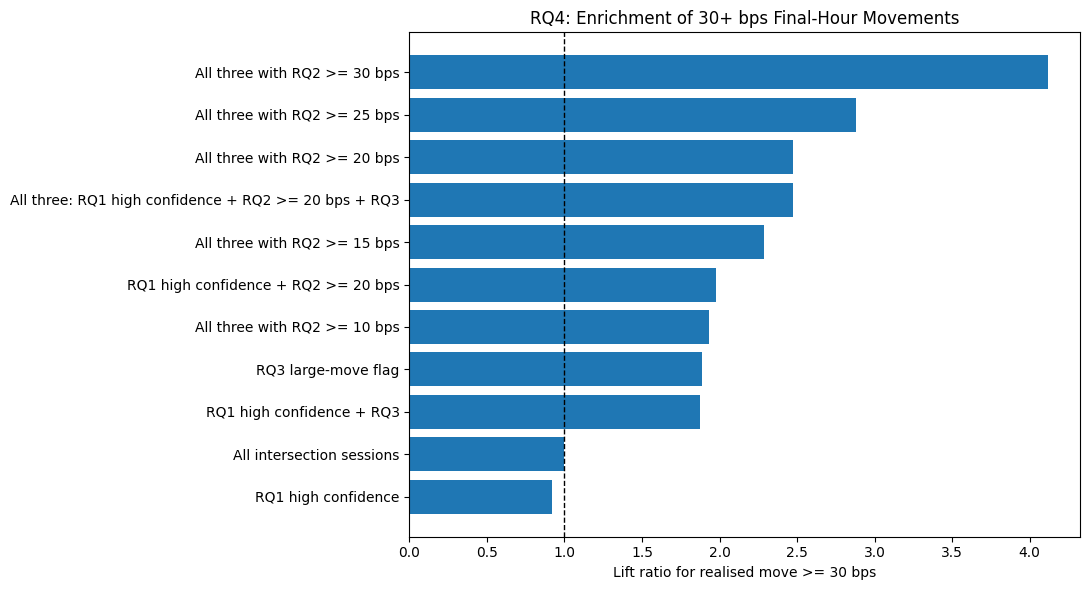

In [10]:
# I use this cell for analysis e - opportunity precision and lift.
opportunity_rows = []

opportunity_masks = dict(key_masks)

for threshold_bps in PREDICTED_MAGNITUDE_THRESHOLDS_BPS:
    mask = (
        combined["rq1_high_confidence"]
        & (combined["rq2_predicted_move_bps"] >= threshold_bps)
        & combined["rq3_positive"]
    )
    opportunity_masks[
        f"All three with RQ2 >= {threshold_bps} bps"
    ] = mask

for realised_threshold in [20, 25, 30, 40, 50]:
    baseline_rate = (
        combined["actual_abs_move_bps"] >= realised_threshold
    ).mean()

    for rule_name, mask in opportunity_masks.items():
        subset = combined[mask]

        event_rate = (
            (subset["actual_abs_move_bps"] >= realised_threshold).mean()
            if len(subset)
            else np.nan
        )

        lift = (
            event_rate / baseline_rate
            if baseline_rate > 0 and np.isfinite(event_rate)
            else np.nan
        )

        opportunity_rows.append(
            {
                "rule": rule_name,
                "realised_move_threshold_bps": realised_threshold,
                "sessions": len(subset),
                "coverage": len(subset) / len(combined),
                "selected_event_rate": event_rate,
                "unconditional_event_rate": baseline_rate,
                "absolute_event_rate_lift": (
                    event_rate - baseline_rate
                    if np.isfinite(event_rate)
                    else np.nan
                ),
                "lift_ratio": lift,
            }
        )

opportunity_lift = pd.DataFrame(opportunity_rows)
display(opportunity_lift)
save_table(opportunity_lift, "rq4_opportunity_precision_and_lift.csv")

plot_data = opportunity_lift[
    opportunity_lift["realised_move_threshold_bps"].eq(30)
].copy()

fig, ax = plt.subplots(figsize=(11, 6))
plot_data = plot_data.sort_values("lift_ratio")
ax.barh(plot_data["rule"], plot_data["lift_ratio"])
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Lift ratio for realised move >= 30 bps")
ax.set_ylabel("")
ax.set_title("RQ4: Enrichment of 30+ bps Final-Hour Movements")
save_figure(fig, "rq4_30bps_opportunity_lift.png")
plt.show()

## 11. RQ2 ranking bridge — Do larger predicted moves correspond to larger realised moves?

RQ2 showed stronger rank correlation than explained variance. For RQ4, the economically relevant question is therefore whether sessions ranked higher by the RQ2 model actually realise larger subsequent movements.

Predictions are divided into quintiles within the available RQ2 outer-fold predictions. This is descriptive development-period evidence and is not used to retune the model.

,predicted_magnitude_quintile,sessions,mean_predicted_move_bps,median_predicted_move_bps,mean_realised_move_bps,median_realised_move_bps,mean_realised_move_points,rate_ge_30bps
0,0,61,8.707968,8.906220,10.855569,9.039117,7.000000,0.049180
1,1,60,11.889387,11.807424,14.012010,10.177046,8.939000,0.116667
2,2,61,14.915469,14.778929,17.816682,14.739745,10.995738,0.147541
3,3,60,20.006055,20.217134,28.954669,19.844917,17.531667,0.383333
4,4,61,29.791666,28.099730,36.950196,26.227990,22.153770,0.442623


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_rq2_predicted_magnitude_quintiles.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\figures\rq4_rq2_magnitude_quintiles.png


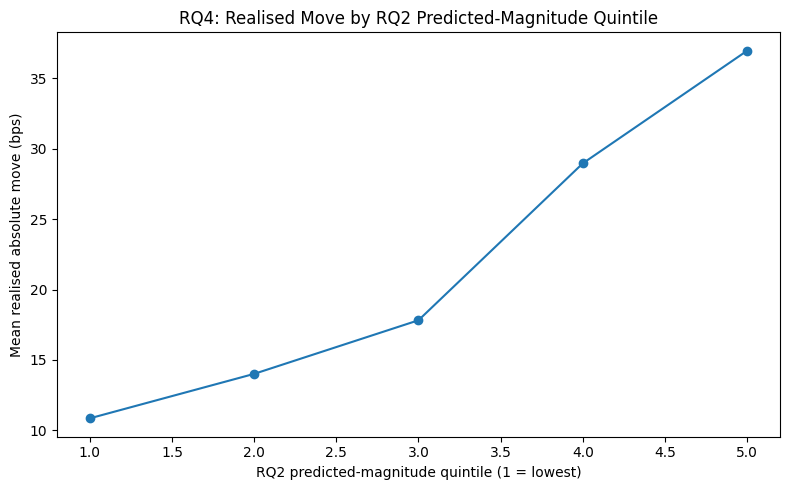

In [11]:
# I use this cell for rq2 ranking bridge - do larger predicted moves correspond to larger realised moves?.
rq2_rank = rq2.copy()

rq2_rank["predicted_magnitude_quintile"] = pd.qcut(
    rq2_rank["prediction"],
    q=5,
    labels=False,
    duplicates="drop",
)

rq2_quintile_summary = (
    rq2_rank
    .groupby("predicted_magnitude_quintile", as_index=False)
    .agg(
        sessions=("session_date", "size"),
        mean_predicted_move_bps=("prediction", "mean"),
        median_predicted_move_bps=("prediction", "median"),
        mean_realised_move_bps=("actual_abs_move_bps", "mean"),
        median_realised_move_bps=("actual_abs_move_bps", "median"),
        mean_realised_move_points=("actual_move_points", "mean"),
        rate_ge_30bps=(
            "actual_abs_move_bps",
            lambda x: float((x >= 30).mean()),
        ),
    )
)

display(rq2_quintile_summary)
save_table(
    rq2_quintile_summary,
    "rq4_rq2_predicted_magnitude_quintiles.csv",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    rq2_quintile_summary["predicted_magnitude_quintile"] + 1,
    rq2_quintile_summary["mean_realised_move_bps"],
    marker="o",
)
ax.set_xlabel("RQ2 predicted-magnitude quintile (1 = lowest)")
ax.set_ylabel("Mean realised absolute move (bps)")
ax.set_title("RQ4: Realised Move by RQ2 Predicted-Magnitude Quintile")
save_figure(fig, "rq4_rq2_magnitude_quintiles.png")
plt.show()

## 12. Regime sensitivity of economically meaningful signals

The regime labels below are inherited directly from the RQ1 outer-fold diagnostics. Their VIX and realised-volatility boundaries were fitted only from the corresponding preceding outer training folds in the robustness notebook.

No new full-sample regime cut-offs are created here.

In [12]:
# I use this cell for regime sensitivity of economically meaningful signals.
regime_columns = [
    "vix_regime",
    "realized_vol_regime",
    "intraday_trend_regime",
]

regime_rows = []

for rule_name, mask in key_masks.items():
    selected = combined[mask].copy()

    for regime_column in regime_columns:
        for regime_value, subset in selected.groupby(regime_column):
            ba = safe_balanced_accuracy(
                subset["actual_up"].astype(int),
                subset["rq1_prediction"].astype(int),
            )

            regime_rows.append(
                {
                    "rule": rule_name,
                    "regime_type": regime_column,
                    "regime": regime_value,
                    "sessions": len(subset),
                    "minimum_sample_met": len(subset) >= MIN_REGIME_SESSIONS,
                    "direction_balanced_accuracy": ba,
                    "direction_accuracy": accuracy_score(
                        subset["actual_up"].astype(int),
                        subset["rq1_prediction"].astype(int),
                    ),
                    "mean_abs_move_bps": subset["actual_abs_move_bps"].mean(),
                    "median_abs_move_bps": subset["actual_abs_move_bps"].median(),
                    "rate_ge_30bps": (
                        subset["actual_abs_move_bps"] >= 30
                    ).mean(),
                    "mean_directional_capture_bps": (
                        subset["directional_capture_bps"].mean()
                    ),
                    "first_date": subset["session_date"].min(),
                    "last_date": subset["session_date"].max(),
                }
            )

rq4_regime_analysis = pd.DataFrame(regime_rows)
display(rq4_regime_analysis)
save_table(
    rq4_regime_analysis,
    "rq4_opportunity_regime_analysis.csv",
)

,rule,regime_type,regime,sessions,minimum_sample_met,direction_balanced_accuracy,direction_accuracy,mean_abs_move_bps,median_abs_move_bps,rate_ge_30bps,mean_directional_capture_bps,first_date,last_date
0,All intersection sessions,vix_regime,High,100,True,0.501610,0.500000,34.742977,24.346310,0.430000,-4.710950,2024-12-19,2026-03-20
1,All intersection sessions,vix_regime,Low,64,True,0.612414,0.609375,11.338842,10.240987,0.062500,0.499187,2024-12-17,2026-01-28
2,All intersection sessions,vix_regime,Medium,112,True,0.513605,0.526786,18.687496,14.529918,0.178571,1.722417,2024-12-18,2026-02-26
3,All intersection sessions,realized_vol_regime,High,113,True,0.540439,0.539823,34.386136,27.332381,0.442478,0.943042,2024-12-18,2026-03-20
4,All intersection sessions,realized_vol_regime,Low,72,True,0.627852,0.638889,9.590845,9.051815,0.000000,1.766559,2024-12-17,2026-03-04
5,All intersection sessions,realized_vol_regime,Medium,91,True,0.440476,0.450549,18.866033,13.952733,0.186813,-5.274641,2024-12-23,2026-03-17
6,All intersection sessions,intraday_trend_regime,Negative pre-15:00 return,140,True,0.556236,0.557143,23.965026,16.688433,0.292857,1.102466,2024-12-17,2026-03-20
7,All intersection sessions,intraday_trend_regime,Positive pre-15:00 return,136,True,0.508034,0.514706,21.602055,12.751177,0.191176,-2.945452,2024-12-20,2026-03-19
8,RQ1 high confidence,vix_regime,High,28,True,0.562500,0.571429,30.203828,19.490290,0.428571,2.416745,2025-01-14,2026-03-20
9,RQ1 high confidence,vix_regime,Low,27,True,0.641667,0.629630,11.259466,10.477466,0.037037,-1.521665,2025-01-17,2026-01-28


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_opportunity_regime_analysis.csv


WindowsPath('C:/Users/hkhat/OneDrive/Desktop/Project/Dissertation/outputs/rq4_economic_meaningfulness/tables/rq4_opportunity_regime_analysis.csv')

## 13. Moving-block bootstrap uncertainty

Financial observations are temporally ordered, so this section uses a simple moving-block bootstrap rather than independently resampling individual days.

The confidence intervals are descriptive uncertainty estimates around the development-period opportunity diagnostics. They do not replace the later untouched holdout.

In [13]:
# I use this cell for moving-block bootstrap uncertainty.
def moving_block_bootstrap_indices(
    n_rows: int,
    block_length: int,
    rng: np.random.Generator,
) -> np.ndarray:
    if n_rows <= 0:
        return np.array([], dtype=int)

    block_length = max(1, min(block_length, n_rows))
    possible_starts = np.arange(0, n_rows - block_length + 1)

    indices = []
    while len(indices) < n_rows:
        start = int(rng.choice(possible_starts))
        indices.extend(range(start, start + block_length))

    return np.asarray(indices[:n_rows], dtype=int)


def percentile_interval(values, confidence_level=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return (np.nan, np.nan)

    alpha = 1.0 - confidence_level
    return (
        float(np.quantile(values, alpha / 2)),
        float(np.quantile(values, 1 - alpha / 2)),
    )


rng = np.random.default_rng(RANDOM_STATE)
bootstrap_records = []

for iteration in range(N_BOOTSTRAPS):
    sampled_index = moving_block_bootstrap_indices(
        len(combined),
        BOOTSTRAP_BLOCK_LENGTH,
        rng,
    )

    sampled = combined.iloc[sampled_index].reset_index(drop=True)

    sampled_primary_rq2 = (
        sampled["rq2_predicted_move_bps"]
        >= PRIMARY_PREDICTED_MAGNITUDE_BPS
    )

    sampled_masks = {
        "All intersection sessions": pd.Series(True, index=sampled.index),
        "RQ1 high confidence": sampled["rq1_high_confidence"],
        "RQ3 large-move flag": sampled["rq3_positive"],
        "RQ1 high confidence + RQ3": (
            sampled["rq1_high_confidence"] & sampled["rq3_positive"]
        ),
        f"RQ1 high confidence + RQ2 >= {PRIMARY_PREDICTED_MAGNITUDE_BPS} bps": (
            sampled["rq1_high_confidence"] & sampled_primary_rq2
        ),
        (
            f"All three: RQ1 high confidence + RQ2 >= "
            f"{PRIMARY_PREDICTED_MAGNITUDE_BPS} bps + RQ3"
        ): (
            sampled["rq1_high_confidence"]
            & sampled_primary_rq2
            & sampled["rq3_positive"]
        ),
    }

    baseline_30_rate = (
        sampled["actual_abs_move_bps"] >= 30
    ).mean()

    for rule_name, mask in sampled_masks.items():
        subset = sampled[mask]

        if len(subset) == 0:
            continue

        ba = safe_balanced_accuracy(
            subset["actual_up"].astype(int),
            subset["rq1_prediction"].astype(int),
        )

        event_rate_30 = (
            subset["actual_abs_move_bps"] >= 30
        ).mean()

        lift_30 = (
            event_rate_30 / baseline_30_rate
            if baseline_30_rate > 0
            else np.nan
        )

        bootstrap_records.append(
            {
                "iteration": iteration,
                "rule": rule_name,
                "sessions": len(subset),
                "balanced_accuracy": ba,
                "mean_abs_move_bps": subset["actual_abs_move_bps"].mean(),
                "event_rate_ge_30bps": event_rate_30,
                "lift_ratio_ge_30bps": lift_30,
                "mean_directional_capture_bps": (
                    subset["directional_capture_bps"].mean()
                ),
            }
        )

bootstrap_draws = pd.DataFrame(bootstrap_records)

bootstrap_summary_rows = []

for rule_name, subset in bootstrap_draws.groupby("rule"):
    row = {"rule": rule_name}

    for metric in [
        "balanced_accuracy",
        "mean_abs_move_bps",
        "event_rate_ge_30bps",
        "lift_ratio_ge_30bps",
        "mean_directional_capture_bps",
    ]:
        low, high = percentile_interval(
            subset[metric],
            confidence_level=CONFIDENCE_LEVEL,
        )
        row[f"{metric}_bootstrap_mean"] = subset[metric].mean()
        row[f"{metric}_ci_low"] = low
        row[f"{metric}_ci_high"] = high

    bootstrap_summary_rows.append(row)

bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)

display(bootstrap_summary)
save_table(
    bootstrap_summary,
    "rq4_moving_block_bootstrap_summary.csv",
)

,rule,balanced_accuracy_bootstrap_mean,balanced_accuracy_ci_low,balanced_accuracy_ci_high,mean_abs_move_bps_bootstrap_mean,mean_abs_move_bps_ci_low,mean_abs_move_bps_ci_high,event_rate_ge_30bps_bootstrap_mean,event_rate_ge_30bps_ci_low,event_rate_ge_30bps_ci_high,lift_ratio_ge_30bps_bootstrap_mean,lift_ratio_ge_30bps_ci_low,lift_ratio_ge_30bps_ci_high,mean_directional_capture_bps_bootstrap_mean,mean_directional_capture_bps_ci_low,mean_directional_capture_bps_ci_high
0,All intersection sessions,0.534665,0.474380,0.595289,22.551043,18.667868,26.960943,0.242185,0.177536,0.307971,1.000000,1.000000,1.000000,-1.177345,-4.973176,2.343581
1,All three: RQ1 high confidence + RQ2 >= 20 bps...,0.654233,0.420541,0.900000,39.494165,27.026766,53.299721,0.631554,0.384615,0.857143,2.636593,1.672691,3.796921,7.604045,-15.087272,30.758831
2,RQ1 high confidence,0.586843,0.482485,0.688117,20.586863,15.669280,26.180003,0.227460,0.129859,0.333424,0.937734,0.613323,1.274249,1.111731,-5.473882,7.473626
3,RQ1 high confidence + RQ2 >= 20 bps,0.577451,0.388869,0.783333,32.981086,21.086229,46.012629,0.496614,0.260829,0.714286,2.060472,1.194116,3.018939,4.237535,-13.589277,22.049855
4,RQ1 high confidence + RQ3,0.597131,0.424970,0.764733,32.563818,23.688412,43.191271,0.469458,0.285623,0.666667,1.950903,1.227929,2.825431,5.465842,-9.828893,19.889458
5,RQ3 large-move flag,0.512179,0.429910,0.596732,35.864148,28.951749,43.857107,0.457885,0.349503,0.561815,1.904879,1.574935,2.319885,-1.807672,-10.032376,5.782254


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq4_economic_meaningfulness\tables\rq4_moving_block_bootstrap_summary.csv


WindowsPath('C:/Users/hkhat/OneDrive/Desktop/Project/Dissertation/outputs/rq4_economic_meaningfulness/tables/rq4_moving_block_bootstrap_summary.csv')

## 14. Conservative RQ4 interpretation generator

The text below is intentionally cautious:

- it does not call RQ4 positive merely because one threshold performs well;
- it distinguishes unconditional direction from selective/opportunity-filter behaviour;
- it does not claim option profitability;
- it treats the strongest observed combined rule as development-period evidence requiring later confirmation.

Review and edit the generated wording before including it in the dissertation.

In [14]:
all_direction = conditional_direction[
    conditional_direction["minimum_realised_move_bps"].eq(0)
].iloc[0]

primary_selective = selective_economic.iloc[
    (selective_economic["requested_coverage"] - PRIMARY_RQ1_COVERAGE)
    .abs()
    .argsort()[:1]
].iloc[0]

candidate_30 = opportunity_lift[
    opportunity_lift["realised_move_threshold_bps"].eq(30)
    & (opportunity_lift["sessions"] >= MIN_REGIME_SESSIONS)
].copy()

if len(candidate_30):
    best_observed_opportunity = (
        candidate_30.sort_values(
            ["lift_ratio", "sessions"],
            ascending=[False, False],
        )
        .iloc[0]
    )
else:
    best_observed_opportunity = None

unconditional_model_ba = all_direction["model_balanced_accuracy"]
unconditional_benchmark_ba = all_direction["mean_reversion_balanced_accuracy"]

selective_ba = primary_selective["model_balanced_accuracy"]
selective_sessions = int(primary_selective["sessions"])
selective_mean_move = primary_selective["mean_abs_move_bps"]

all_mean_move = selective_economic.loc[
    selective_economic["requested_coverage"].eq(1.0),
    "mean_abs_move_bps",
].iloc[0]

if (
    np.isfinite(unconditional_model_ba)
    and np.isfinite(unconditional_benchmark_ba)
    and unconditional_model_ba <= unconditional_benchmark_ba
):
    rq1_clause = (
        "Unconditional directional forecasting did not outperform the "
        "60-minute mean-reversion comparator on the same outer-fold observations"
    )
else:
    rq1_clause = (
        "Unconditional directional forecasting modestly exceeded the "
        "60-minute mean-reversion comparator on the same outer-fold observations"
    )

if best_observed_opportunity is not None:
    opportunity_clause = (
        f"The highest observed development-period enrichment for a 30+ bps move "
        f"among rules retaining at least {MIN_REGIME_SESSIONS} sessions was "
        f"{best_observed_opportunity['lift_ratio']:.2f}x "
        f"({int(best_observed_opportunity['sessions'])} sessions) under "
        f"'{best_observed_opportunity['rule']}'. "
        "Because this rule is identified from development-period diagnostics, "
        "it should not be interpreted as independently confirmed."
    )
else:
    opportunity_clause = (
        "No combined rule retained enough observations for a stable 30+ bps "
        "opportunity-enrichment comparison."
    )

if (
    selective_ba > unconditional_model_ba
    and selective_mean_move > all_mean_move
):
    selective_clause = (
        f"At the pre-specified {PRIMARY_RQ1_COVERAGE:.0%} confidence coverage "
        f"level, balanced accuracy increased to {selective_ba:.3f} across "
        f"{selective_sessions} sessions and the mean absolute move increased "
        f"from {all_mean_move:.2f} to {selective_mean_move:.2f} bps. "
        "This suggests that model confidence may have value as an opportunity "
        "filter rather than as an unconditional daily forecasting rule."
    )
elif selective_ba > unconditional_model_ba:
    selective_clause = (
        f"At the pre-specified {PRIMARY_RQ1_COVERAGE:.0%} confidence coverage "
        f"level, balanced accuracy increased to {selective_ba:.3f} across "
        f"{selective_sessions} sessions, but the selected observations did not "
        "also show a larger mean realised move. This provides only partial "
        "evidence of economic usefulness."
    )
else:
    selective_clause = (
        f"Restricting RQ1 to the pre-specified {PRIMARY_RQ1_COVERAGE:.0%} "
        "confidence coverage did not materially strengthen directional "
        "performance relative to the unconditional result."
    )

rq4_draft = f"""
### RQ4: Economic Meaningfulness of the Predictive Signals

{rq1_clause}. The selected RQ1 model achieved unconditional balanced accuracy
of {unconditional_model_ba:.3f}, compared with
{unconditional_benchmark_ba:.3f} for the 60-minute mean-reversion rule.
Therefore, the machine-learning direction model should not be considered
economically useful solely on the basis of its unconditional directional score.

{selective_clause}

The RQ2 and RQ3 models were additionally used as opportunity filters rather
than as direct trading strategies. RQ2 supplied an estimate of absolute movement
magnitude, while RQ3 identified sessions with elevated large-movement risk.
{opportunity_clause}

Overall, RQ4 should be interpreted in terms of whether the models concentrate
larger and more directionally predictable SPX movements into a smaller subset
of sessions. Any such enrichment is evidence of potential economic relevance,
not evidence of profitability. Whether the identified opportunities can overcome
0DTE option premiums, bid-ask spreads, slippage, commissions, rapid time decay
and realistic execution constraints remains an empirical question for RQ5.
"""

print(rq4_draft)

RQ4_DRAFT_PATH = RQ4_ROOT / "rq4_dissertation_draft.md"
RQ4_DRAFT_PATH.write_text(rq4_draft, encoding="utf-8")
print("Saved:", RQ4_DRAFT_PATH)


### RQ4: Economic Meaningfulness of the Predictive Signals

Unconditional directional forecasting did not outperform the 60-minute mean-reversion comparator on the same outer-fold observations. The selected RQ1 model achieved unconditional balanced accuracy
of 0.532, compared with
0.567 for the 60-minute mean-reversion rule.
Therefore, the machine-learning direction model should not be considered
economically useful solely on the basis of its unconditional directional score.

At the pre-specified 30% confidence coverage level, balanced accuracy increased to 0.592 across 93 sessions, but the selected observations did not also show a larger mean realised move. This provides only partial evidence of economic usefulness.

The RQ2 and RQ3 models were additionally used as opportunity filters rather
than as direct trading strategies. RQ2 supplied an estimate of absolute movement
magnitude, while RQ3 identified sessions with elevated large-movement risk.
The highest observed development-perio

## 15. Output inventory and hand-off to RQ5

In [ ]:
# I use this cell for output inventory and hand-off to rq5.
output_inventory = pd.DataFrame(
    {
        "artifact": [
            "Direction conditional on realised move",
            "RQ1 confidence/economic analysis",
            "Combined outer-fold prediction intersection",
            "Combined signal summary",
            "SPX point-move summary",
            "SPX point-move distribution",
            "Opportunity precision and lift",
            "RQ2 predicted-magnitude quintiles",
            "Opportunity regime analysis",
            "Moving-block bootstrap summary",
            "RQ4 dissertation draft",
            "RQ4 figures",
        ],
        "path": [
            str(RQ4_TABLE_ROOT / "rq4_direction_conditional_on_realised_move.csv"),
            str(RQ4_TABLE_ROOT / "rq4_rq1_confidence_economic_analysis.csv"),
            str(RQ4_TABLE_ROOT / "rq4_combined_outer_fold_predictions.csv"),
            str(RQ4_TABLE_ROOT / "rq4_combined_signal_summary.csv"),
            str(RQ4_TABLE_ROOT / "rq4_spx_point_move_summary.csv"),
            str(RQ4_TABLE_ROOT / "rq4_spx_point_move_distribution.csv"),
            str(RQ4_TABLE_ROOT / "rq4_opportunity_precision_and_lift.csv"),
            str(RQ4_TABLE_ROOT / "rq4_rq2_predicted_magnitude_quintiles.csv"),
            str(RQ4_TABLE_ROOT / "rq4_opportunity_regime_analysis.csv"),
            str(RQ4_TABLE_ROOT / "rq4_moving_block_bootstrap_summary.csv"),
            str(RQ4_DRAFT_PATH),
            str(RQ4_FIGURE_ROOT),
        ],
    }
)

display(output_inventory)

print("RQ4 workflow completed.")
print("No fresh post-17 July 2026 holdout data were loaded.")
print(
    "Next stage: RQ5 should map a pre-specified subset of these signals to "
    "actual 0DTE SPX option contracts and evaluate realistic execution/P&L."
)

,artifact,path
0,Direction conditional on realised move,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
1,RQ1 confidence/economic analysis,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
2,Combined outer-fold prediction intersection,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
3,Combined signal summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
4,SPX point-move summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
5,SPX point-move distribution,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
6,Opportunity precision and lift,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
7,RQ2 predicted-magnitude quintiles,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
8,Opportunity regime analysis,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
9,Moving-block bootstrap summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...


RQ4 workflow completed.
No fresh post-17 July 2026 holdout data were loaded.
Next stage: RQ5 should map a pre-specified subset of these signals to actual 0DTE SPX option contracts and evaluate realistic execution/P&L.


: 